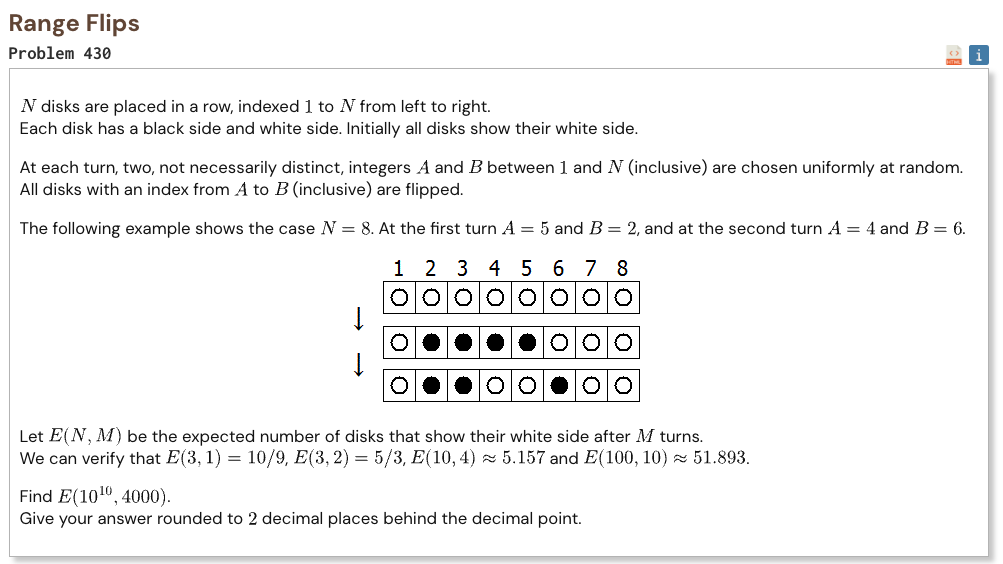

## Initial approach

-   start from half of all disks, since disks far from the edges are almost equally likely to be white or black
-   handle each disk separately because expectation can be added even though the flips are not independent between disks
-   find the probability that a randomly chosen range contains a particular disk
-   after many turns, use the probability of an even number of flips to get the chance that the disk is white
-   disks at equal distances from the two ends have the same probability, so only calculate one side
-   the correction becomes extremely small after enough disks, so stop when the remaining contribution cannot affect two decimal places
-   add the symmetric edge corrections to the half-white baseline and round the result

In [1]:
%%time

N = 10**10
M = 4000

result = N / 2
correction = 0.0

i = 1

while i <= N // 2:
    flip_prob = (2 * i * (N - i + 1) - 1) / (N * N)
    balance = 1 - 2 * flip_prob
    extra = 0.5 * (balance ** M)

    correction += extra

    if extra < 1e-15:
        break

    i += 1

result += 2 * correction

print("Result:", round(result, 2))

Result: 5000624921.38
CPU times: user 8.87 s, sys: 45.1 ms, total: 8.92 s
Wall time: 9.09 s
